<a href="https://colab.research.google.com/github/ketaki-data/Apple--sales--dashboard/blob/main/Apple_project1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/drive/MyDrive/apple_global_sales_dataset.csv")
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

,0
sale_id,0
sale_date,0
year,0
quarter,0
month,0
country,0
region,0
city,0
product_name,0
category,0


In [ ]:
df.drop_duplicates(inplace =True)

In [ ]:
df['sale_date']= pd.to_datetime(df['sale_date'],errors='coerce')
df['year']= df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month
df['quarter'] = df['sale_date'].dt.quarter

In [ ]:
df['revenue_usd'] = df['revenue_usd'].replace('[$,]', "", regex = True ).astype(float)
df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce')

In [ ]:
df = df.dropna(subset=['revenue_usd','units_sold'])

In [ ]:
country_revenue = df.groupby('country').agg({
    'revenue_usd':'sum',
    'units_sold':'sum'
}).sort_values(by='revenue_usd',ascending=False)
country_revenue.head(10)

,revenue_usd,units_sold
country,,
Hong Kong,485261.23,530
Netherlands,455560.33,509
Mexico,454405.84,550
Canada,451801.06,537
Turkey,450007.23,533
Saudi Arabia,444411.63,494
Germany,444195.10,494
Japan,440942.04,576
Malaysia,432614.73,547


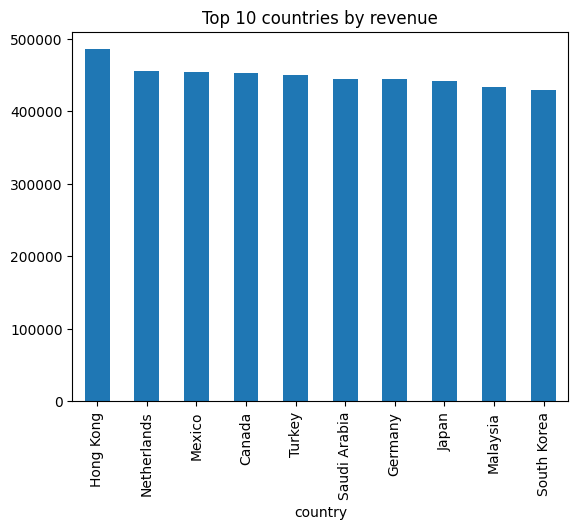

In [ ]:
plt.figure()
country_revenue['revenue_usd'].head(10).plot(kind='bar')
plt.title("Top 10 countries by revenue")
plt.show()

In [ ]:
region_category = df.groupby(['region','category'])['revenue_usd'].sum().reset_index()
region_total = df.groupby('region')['revenue_usd'].sum().reset_index()
region_category = region_category.merge(region_total,on='region',suffixes =('','_Total'))
region_category['revenue_usd_Percent'] =(
    region_category['revenue_usd']/region_category['revenue_usd_Total']*100
)
region_category.head()

,region,category,revenue_usd,revenue_usd_Total,revenue_usd_Percent
0,Africa,Accessories,49765.73,1379004.44,3.608816
1,Africa,AirPods,42217.73,1379004.44,3.061464
2,Africa,Apple Watch,69393.22,1379004.44,5.032124
3,Africa,Mac,610980.11,1379004.44,44.305884
4,Africa,iPad,144040.93,1379004.44,10.445284


In [ ]:
channel_perf = df.groupby(['country','sales_channel']).agg({
    'revenue_usd':'sum',
    'units_sold':'sum'
}).reset_index()
channel_perf['ASP'] = channel_perf['revenue_usd']/channel_perf['units_sold']
channel_perf.head()

,country,sales_channel,revenue_usd,units_sold,ASP
0,Argentina,Apple Store,54867.08,87,630.656092
1,Argentina,Authorized Reseller,53229.73,107,497.474112
2,Argentina,Carrier Store,69550.37,83,837.956265
3,Argentina,Corporate / B2B,68328.99,104,657.009519
4,Argentina,Online (Apple.com),62858.56,86,730.913488


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/apple_global_sales_dataset.csv")
df.head()

Mounted at /content/drive


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [ ]:
df['discount_pct'] = ((df['unit_price_usd'] - df['discounted_price_usd']) / df['unit_price_usd']) * 100

In [ ]:
df[['discount_pct', 'unit_price_usd','revenue_usd']].corr()

,discount_pct,unit_price_usd,revenue_usd
discount_pct,1.000000,-0.010307,-0.038354
unit_price_usd,-0.010307,1.000000,0.755070
revenue_usd,-0.038354,0.755070,1.000000


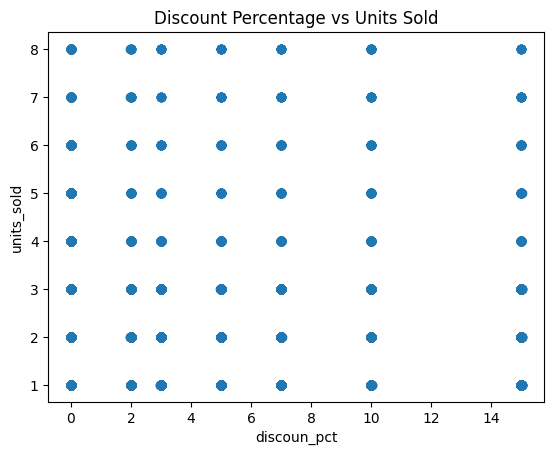

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['discount_pct'],df['units_sold'])
plt.xlabel("discoun_pct")
plt.ylabel("units_sold")
plt.title("Discount Percentage vs Units Sold")
plt.show()

In [ ]:
#seasonality (quarter analysis)
quarter_analysis = df.groupby(['quarter','category'])['revenue_usd'].sum().reset_index()
quarter_analysis.head()

,quarter,category,revenue_usd
0,Q1,Accessories,140766.51
1,Q1,AirPods,145578.69
2,Q1,Apple Watch,229179.20
3,Q1,Mac,2131760.76
4,Q1,iPad,467533.23


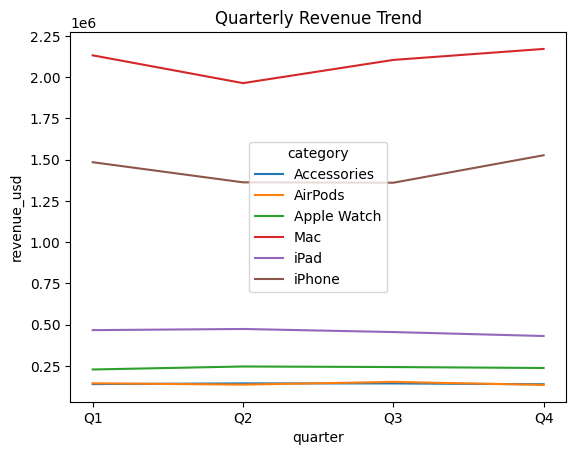

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#line trend
sns.lineplot(data=quarter_analysis,x='quarter',y='revenue_usd',hue='category')
plt.title("Quarterly Revenue Trend")
plt.show()

In [ ]:
#currency normalization
df['revenue_usd'] = df['revenue_local_currency'] / df['fx_rate_to_usd']

In [ ]:
#customer segmentation
segment_analysis = df.groupby('customer_segment')['revenue_usd'].sum().reset_index()
segment_analysis.head()

,customer_segment,revenue_usd
0,Business,4.455762e+06
1,Education,4.635789e+06
2,Government,4.493436e+06
3,Individual,4.450683e+06


In [ ]:
# Re-group by customer_segment to get both revenue and units sold for average order value calculation
segment_performance = df.groupby('customer_segment').agg(
    revenue_usd=('revenue_usd', 'sum'),
    units_sold=('units_sold', 'sum')
).reset_index()

# Calculate average order value
segment_performance['avg_order_value'] = segment_performance['revenue_usd'] / segment_performance['units_sold']

print(segment_performance.head())

  customer_segment   revenue_usd  units_sold  avg_order_value
0         Business  4.455762e+06        5771       772.095275
1        Education  4.635789e+06        5760       804.824448
2       Government  4.493436e+06        5882       763.929888
3       Individual  4.450683e+06        5857       759.891259


In [ ]:
#os switching
switch_rate =( # Renamed variable from switch_% to switch_rate
    df[df['previous_device_os'] == 'android'].shape[0]/df.shape[0]
) *100
print("android to iphone switch%:",switch_rate) # Used corrected variable name

android to iphone switch%: 0.0


In [ ]:
#age group preference
age_pref = df.groupby(['customer_age_group', 'category'])['revenue_usd'].sum().reset_index()
age_pref.head()


,customer_age_group,category,revenue_usd
0,18–24,Accessories,1.048180e+05
1,18–24,AirPods,1.105260e+05
2,18–24,Apple Watch,1.934716e+05
3,18–24,Mac,1.461636e+06
4,18–24,iPad,3.665426e+05


In [ ]:
df.to_csv("cleaned_apple_sales.csv",index = False)

In [ ]:
from google.colab import files
files.download("cleaned_apple_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>